## Advanced Task Set

## Task 6: Term Deposit Subscription Prediction (Bank Marketing)

### Objective:

- Predict whether a customer will subscribe to a term deposit using bank marketing data.

## Import Libraries

In [34]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    roc_curve,
    roc_auc_score
)

import shap
import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [35]:
df = pd.read_csv("bank.csv", sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


## Data Understanding

In [36]:
df.shape

(4521, 17)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [38]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [39]:
df['y'].value_counts()

y
no     4000
yes     521
Name: count, dtype: int64

## EDA (Basic Insights)

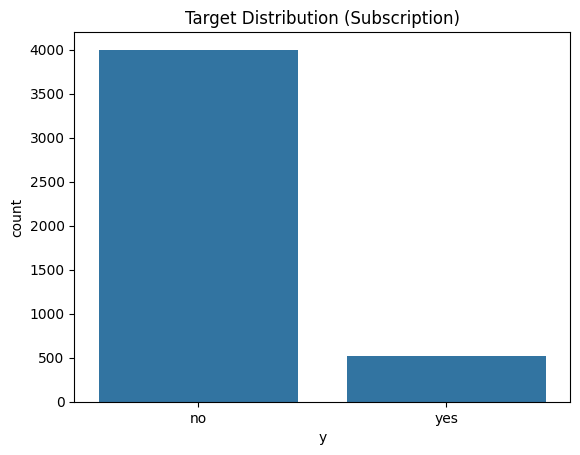

In [40]:
sns.countplot(x='y', data=df)
plt.title("Target Distribution (Subscription)")
plt.show()

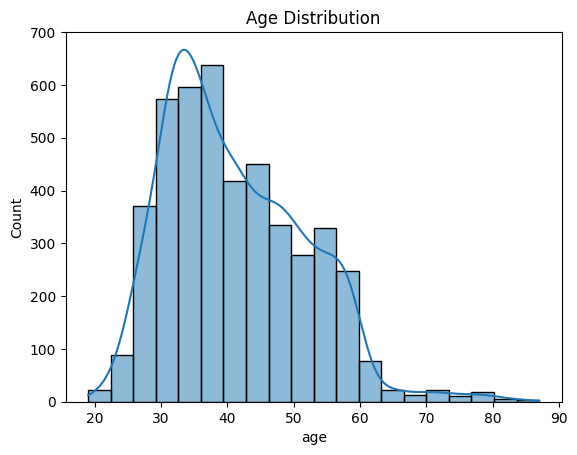

In [41]:
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

## Data Preprocessing (Encoding)

In [42]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,10,1,0,0,1787,0,0,0,19,10,79,1,-1,0,3,0
1,33,7,1,1,0,4789,1,1,0,11,8,220,1,339,4,0,0
2,35,4,2,2,0,1350,1,0,0,16,0,185,1,330,1,0,0
3,30,4,1,2,0,1476,1,1,2,3,6,199,4,-1,0,3,0
4,59,1,1,1,0,0,1,0,2,5,8,226,1,-1,0,3,0


## Split Data

In [43]:
X = df.drop('y', axis=1)
y = df['y']

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Model 1: Logistic Regression

In [45]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

## Evaluation

### Confusion Matrix

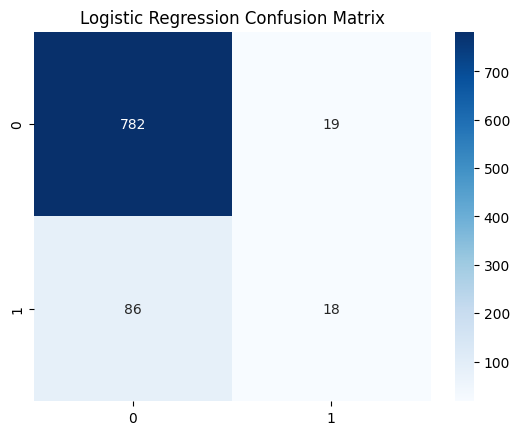

In [46]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

### F1 Score

In [47]:
f1_lr = f1_score(y_test, y_pred_lr)
print("F1 Score:", f1_lr)

F1 Score: 0.2553191489361702


### ROC Curve

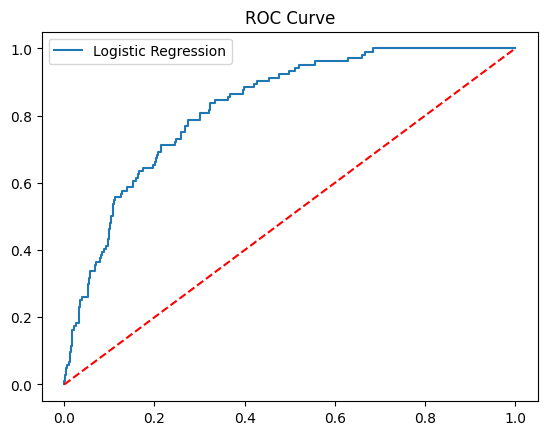

ROC-AUC: 0.8272711994622106


In [48]:
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1],[0,1],'r--')
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

## Model 2: Random Forest

In [49]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

## Evaluation

### Confusion Matrix

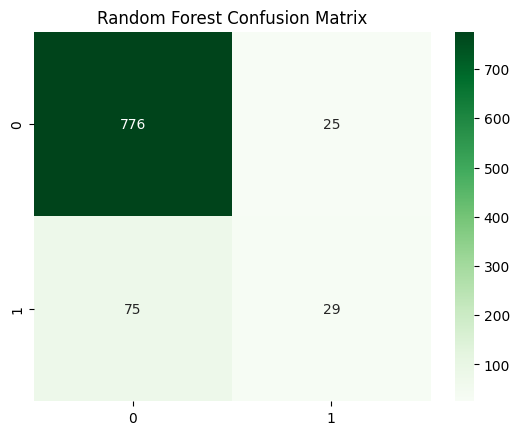

In [50]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.show()

### F1 Score

In [51]:
f1_rf = f1_score(y_test, y_pred_rf)
print("F1 Score:", f1_rf)

F1 Score: 0.3670886075949367


### ROC Curve

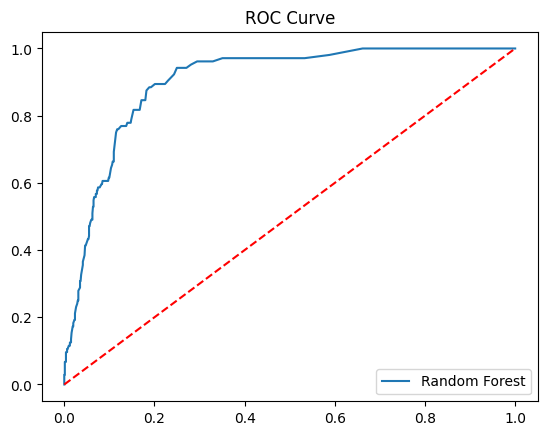

ROC-AUC: 0.9021955728416403


In [52]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1],[0,1],'r--')
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

## Model Comparison

In [53]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "F1 Score": [f1_lr, f1_rf],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results

,Model,F1 Score,ROC-AUC
0,Logistic Regression,0.255319,0.827271
1,Random Forest,0.367089,0.902196


## Explainable AI (SHAP)

### Create Explainer

In [54]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

### Feature Importance

In [55]:
print("X_test shape:", X_test.shape)
print("SHAP shape:", shap_values[1].shape)

X_test shape: (905, 16)
SHAP shape: (16, 2)


In [58]:
import shap

explainer = shap.Explainer(rf, X_train)
shap_values = explainer(X_test)

Background dataset has 3616 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3616 when initializing the masker.
 99%|===================| 1798/1810 [01:27<00:00]        

In [59]:
print(shap_values.shape)

(905, 16, 2)


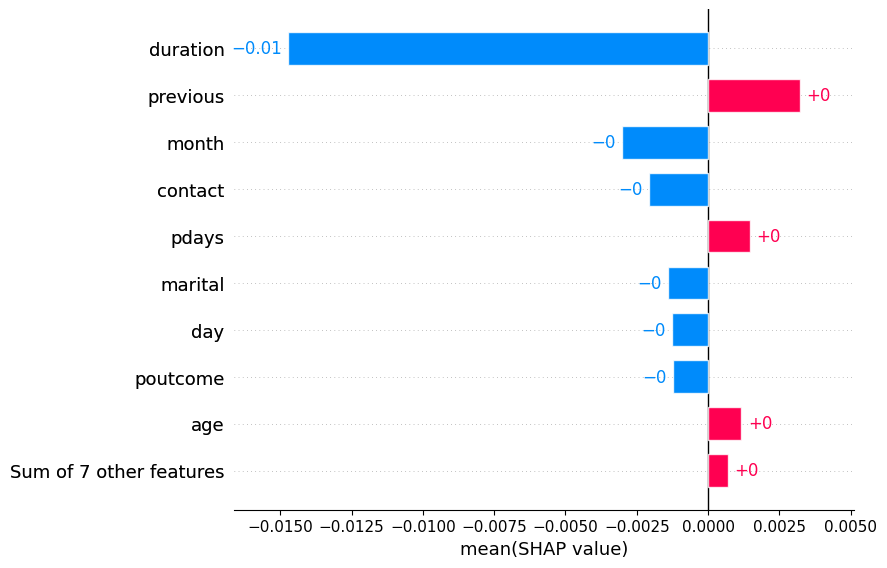

In [60]:
shap.plots.bar(shap_values[:, :, 1].mean(0))

### Global explanation:

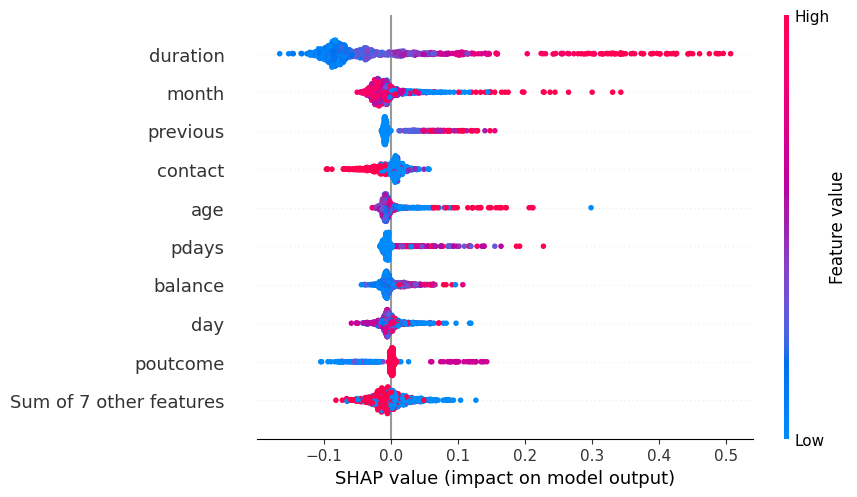

In [61]:
shap.plots.beeswarm(shap_values[:, :, 1])

## Explain 5 Predictions (REQUIRED)

### Prediction 1

In [64]:
import shap

explainer = shap.Explainer(rf, X_train)
shap_values = explainer(X_test)

Background dataset has 3616 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3616 when initializing the masker.
 99%|===================| 1793/1810 [01:27<00:00]        

In [66]:
print(shap_values.shape)

(905, 16, 2)


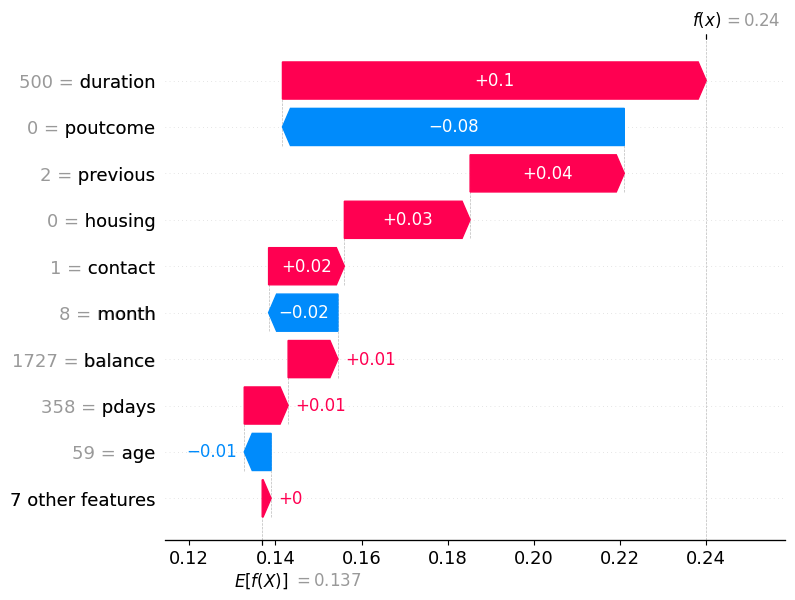

In [67]:
shap.plots.waterfall(shap_values[0, :, 1])

### Prediction 2

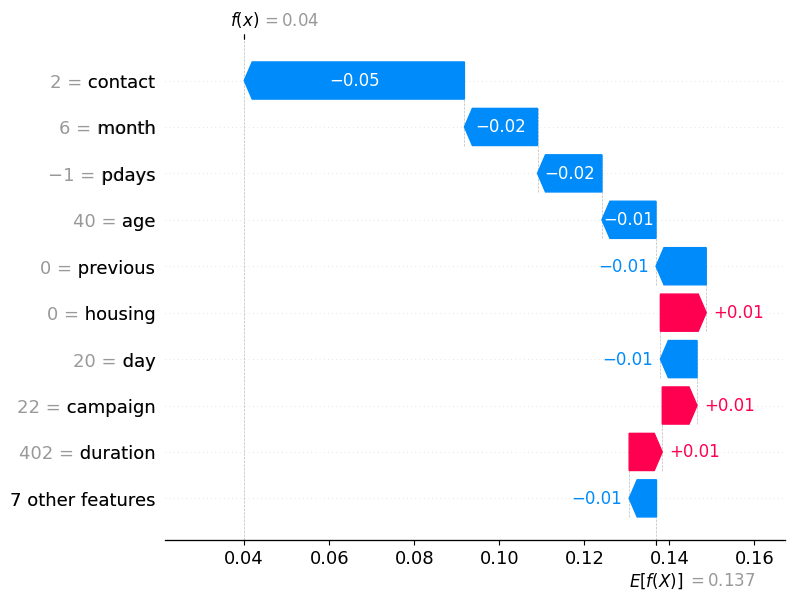

In [69]:
shap.plots.waterfall(shap_values[1, :, 1])

### Prediction 3

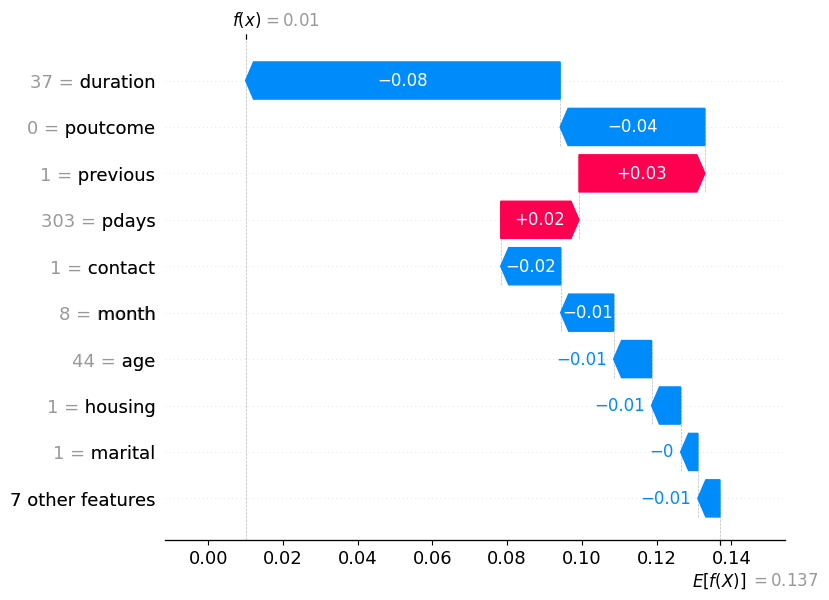

In [70]:
shap.plots.waterfall(shap_values[2, :, 1])

### Prediction 4

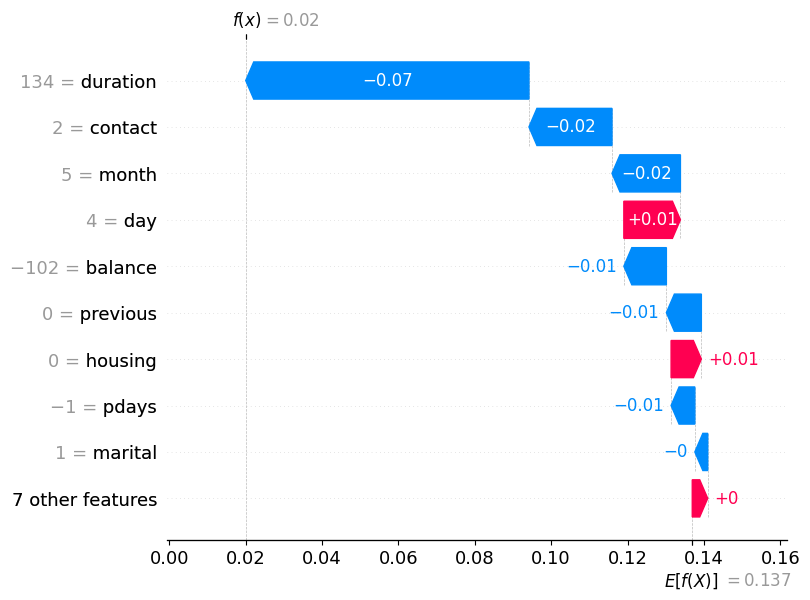

In [71]:
shap.plots.waterfall(shap_values[3, :, 1])

### Prediction 5

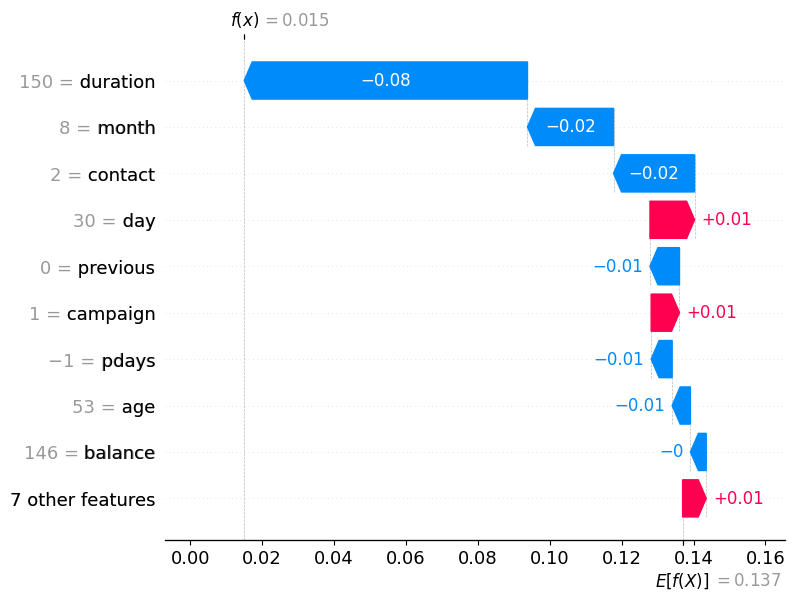

In [72]:
shap.plots.waterfall(shap_values[4, :, 1])

## Final Insights

- Most customers do not subscribe to term deposits.
- Duration of call is the strongest predictor of subscription.
- Previous campaign outcome strongly affects customer response.
- Customers with housing loans are less likely to subscribe.
- Random Forest performs better than Logistic Regression in this dataset.
- SHAP shows that duration, balance, and contact type are key drivers of prediction.

## Conclusion

This project successfully predicted whether a bank customer will subscribe to a term deposit using machine learning models.

Two models were implemented:
- Logistic Regression
- Random Forest Classifier

Model performance was evaluated using:
- Confusion Matrix
- F1 Score
- ROC Curve
- ROC-AUC Score

Random Forest performed better in capturing complex patterns in the data.

To ensure transparency and interpretability, SHAP (SHapley Additive exPlanations) was used. It explained individual predictions by showing how each feature contributed to the final decision.

This project demonstrates practical skills in:
- Data preprocessing
- Classification modeling
- Model evaluation
- Explainable AI (XAI)
- Business decision analysis

___________________________